# Weighting links by their expected error

A link's error depends on its length: the wet-antenna offset does not grow with the path, so on a short link
it is a large share of the signal. Here the error of each length bin is learned on half the storms of
`maps/multisensor` (link total against the radar along its path), and used on the other half as an IDW
weight (inverse error variance). The numbers come from `python src/run.py`.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
from core.viz_style import use_style
from link_weights import study
from link_weights.settings import RESULTS_DIR

use_style()
model = pd.read_csv(RESULTS_DIR / "error_model.csv")
scores = pd.read_csv(RESULTS_DIR / "test_scores.csv")
events = pd.read_csv(RESULTS_DIR / "events.csv")
events.groupby(["network", "split"]).size().unstack()

split,test,train
network,,
openmesh,5,5
openmrg,5,5
openrainer,5,5


## Error by link length, training storms
NRMSE and relative bias of hourly link totals against the radar along the path.

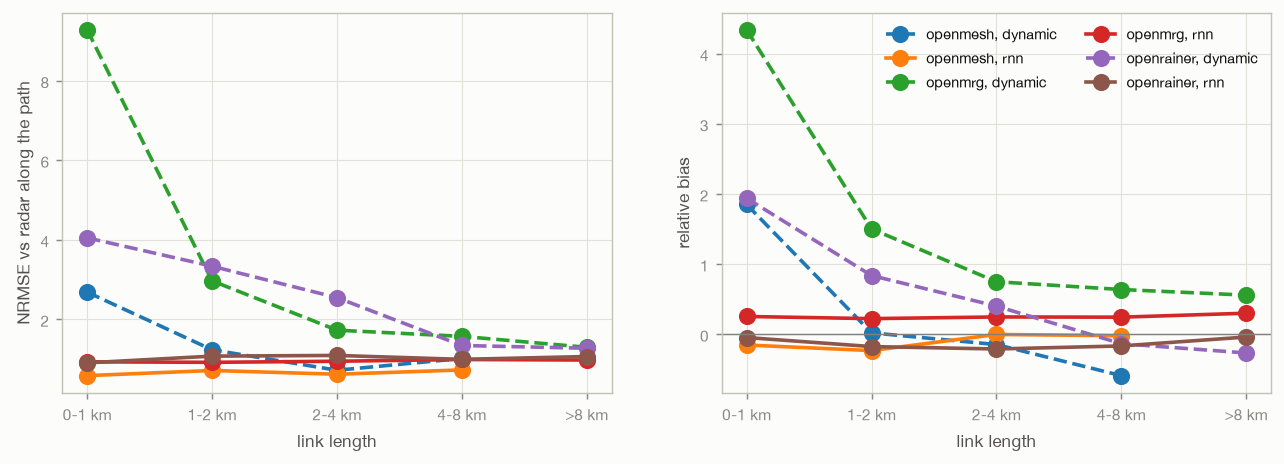

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for (net, ret), d in model.groupby(["network", "retrieval"]):
    ls = "-" if ret == "rnn" else "--"
    axes[0].plot(d["bin"], d["nrmse"], ls, marker="o", label=f"{net}, {ret}")
    axes[1].plot(d["bin"], d["rel_bias"], ls, marker="o", label=f"{net}, {ret}")
axes[0].set_ylabel("NRMSE vs radar along the path")
axes[1].set_ylabel("relative bias")
axes[1].axhline(0, color="0.5", lw=0.8)
for ax in axes:
    ax.set_xlabel("link length")
axes[1].legend(fontsize=8, ncol=2)
plt.show()

## Maps on the test storms
Median over test storms; held-out gauges and the radar on the map grid.

In [3]:
s = study.summary(scores)
s.pivot_table(index=["reference", "network", "retrieval"], columns="map", values="nrmse")

map                               idw  idw weighted by length error  \
reference network    retrieval                                        
gauges    openmesh   dynamic    1.562                         0.949   
                     rnn        0.735                         0.722   
          openmrg    dynamic    3.624                         2.326   
                     rnn        0.653                         0.658   
          openrainer dynamic    2.605                         2.362   
                     rnn        1.508                         1.510   
radar     openmesh   dynamic    1.336                         0.956   
                     rnn        0.601                         0.588   
          openmrg    dynamic    2.314                         2.051   
                     rnn        1.554                         1.557   
          openrainer dynamic    3.336                         2.969   
                     rnn        1.331                         1.331   

map                             idw without links < 1 km  
reference network    retrieval                            
gauges    openmesh   dynamic                       0.926  
                     rnn                           0.762  
          openmrg    dynamic                       2.212  
                     rnn                           0.635  
          openrainer dynamic                       2.568  
                     rnn                           1.521  
radar     openmesh   dynamic                       0.897  
                     rnn                           0.621  
          openmrg    dynamic                       2.136  
                     rnn                           1.552  
          openrainer dynamic                       3.255  
                     rnn                           1.337

## What it shows

- **Power-law links read far too high on short paths**: below 1 km the dynamic-baseline retrieval is +434% in
  Gothenburg and about +190% in Emilia-Romagna and New York; above 4 km the bias is a fraction of that.
  The constant wet-antenna offset is the likely cause.
- **Weighting by the learned error repairs most of the power-law map**: at held-out gauges NRMSE falls from
  3.62 to 2.33 in Gothenburg, 1.56 to 0.95 in New York and 2.61 to 2.36 in Emilia-Romagna. Simply dropping
  the links under 1 km does about as well in Gothenburg and New York, not in Emilia-Romagna.
- **The RNN's error is flat across lengths**, so weighting changes nothing for it: it has learned the
  length-dependent offset that the power law misses.